# K-Means Clustering
K-Means is an unsupervised Machine Learning algorithm used to divide data into groups called clusters.

The important difference:

*Supervised Learning* \
We have the answer (y). \
Input → Model → Known Target \
Examples: \
Pass/Fail \
Spam/Not Spam \
House price 

*Unsupervised Learning* \
We don't have a target column. \
Data → Model → Groups \
K-Means discovers the groups itself.

**Example**  \
Imagine we have customers:

| Customer | Age | Spending |
| -------- | --: | -------: |
| A        |  20 |       90 |
| B        |  22 |       85 |
| C        |  25 |       80 |
| D        |  45 |       30 |
| E        |  48 |       25 |
| F        |  50 |       20 |

We don't tell the model which customer belongs to which group. \
K-Means might discover:

Cluster 1 \
Young + High Spending \
A \
B \
C

Cluster 2 \
Older + Low Spending \ 
D \
E \
F

The algorithm found these groups from the data.

## What Does "K" Mean?

K = Number of clusters we want.

For example: *KMeans(n_clusters=2)* \
means: Create 2 clusters

## Why is K-Means Unsupervised?

Suppose our dataset is:

|Age |   Spending |
|----|------------|
|20  |     90     |  
|22  |     85     |
|25  |     80     |
|45  |     30     |
|48  |     25     |
|50  |     20     |

There is no: Cluster column. \
We only give K-Means the features: \
Age \
Spending

It tries to discover the structure itself.

## How K-Means Works
K-Means follows roughly these steps:

1. Choose K \
      ↓
2. Randomly initialize cluster centers \
      ↓
3. Assign each point to its nearest center \
      ↓
4. Recalculate the centers \
      ↓
5. Assign points again \
      ↓
6. Repeat until centers stop changing

## Step 1: Choose K

Suppose: K = 2 \
We want: \
Cluster 0 \
Cluster 1

## Step 2: Create Centroids
A centroid is the center of a cluster.

## Step 3: Assign Points
Each data point is assigned to the nearest centroid.

Point \
  ↓ \
Which centroid is closest? \
  ↓ \
Assign to that cluster

## Step 4: Recalculate Centroids

After assigning the points, K-Means calculates a new center for each cluster.\
For example: 

Cluster 1 \
10 \
20 \
30

The center is: 20 \
Then the algorithm moves the centroid.

## Step 5 — Repeat
K-Means keeps doing:

Assign \
 ↓ \
Calculate center \
 ↓ \
Assign \
 ↓ \
Calculate center \
 ↓ \
...

until the clusters stabilize.

## Customer Segmentation Project

In [1]:
import pandas as pd   #Used for DataFrames.
import matplotlib.pyplot as plt  #Used to visualize the clusters.
from sklearn.cluster import KMeans  #This is the actual K-Means algorithm.
from sklearn.preprocessing import StandardScaler  #put features on comparable scales.

In [2]:
data = {
    "Age": [
        20, 22, 25, 27, 30,
        45, 48, 50, 52, 55
    ],
    "Income": [
        20000, 22000, 25000, 27000, 30000,
        60000, 65000, 70000, 75000, 80000
    ],
    "Spending": [
        90, 85, 80, 75, 70,
        30, 25, 20, 15, 10
    ]
}

df = pd.DataFrame(data)
print(df)

   Age  Income  Spending
0   20   20000        90
1   22   22000        85
2   25   25000        80
3   27   27000        75
4   30   30000        70
5   45   60000        30
6   48   65000        25
7   50   70000        20
8   52   75000        15
9   55   80000        10


In [3]:
X = df[["Age", "Income", "Spending"]]

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
model = KMeans(n_clusters=2, random_state=42, n_init=10)

In [7]:
model.fit(X_scaled)

,n_clusters,2
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [10]:
model.fit(X)

,n_clusters,2
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [12]:
clusters = model.labels_
print(clusters)

[0 0 0 0 0 1 1 1 1 1]


In [13]:
df["Cluster"] = clusters
print(df)

   Age  Income  Spending  Cluster
0   20   20000        90        0
1   22   22000        85        0
2   25   25000        80        0
3   27   27000        75        0
4   30   30000        70        0
5   45   60000        30        1
6   48   65000        25        1
7   50   70000        20        1
8   52   75000        15        1
9   55   80000        10        1


In [14]:
print(model.cluster_centers_)

[[2.48e+01 2.48e+04 8.00e+01]
 [5.00e+01 7.00e+04 2.00e+01]]


In [15]:
centers = scaler.inverse_transform(model.cluster_centers_)
print(centers)

[[3.61550326e+02 5.77434862e+08 2.51576560e+03]
 [6.90928882e+02 1.62977008e+09 6.66441400e+02]]


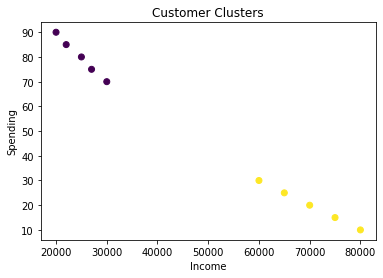

In [16]:
plt.scatter(
    df["Income"],
    df["Spending"],
    c=df["Cluster"]
)

plt.xlabel("Income")
plt.ylabel("Spending")
plt.title("Customer Clusters")
plt.show()

In [17]:
inertia = []

for k in range(1, 7):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(
        model.inertia_
    )

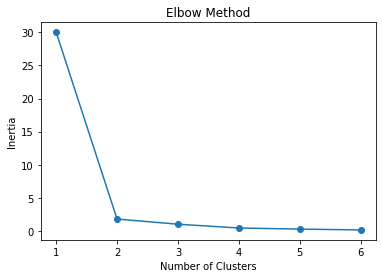

In [19]:
plt.plot(
    range(1, 7),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

## What Does the Elbow Mean?
      
At first, increasing K causes a large improvement. \
Then the improvement becomes smaller. \
The point where the curve bends is called the **elbow**. \
That can be a useful candidate for K. \

However, don't blindly choose the elbow. domain knowledge and other validation methods can also matter.

## K-Means vs Previous Algorithms

| Algorithm           | Learning         | Main Purpose              |
| ------------------- | ---------------- | ------------------------- |
| Linear Regression   | Supervised       | Predict number            |
| Logistic Regression | Supervised       | Classification            |
| Decision Tree       | Supervised       | Classification/Regression |
| Random Forest       | Supervised       | Classification/Regression |
| KNN                 | Supervised       | Classification/Regression |
| Naive Bayes         | Supervised       | Classification            |
| SVM                 | Supervised       | Classification/Regression |
| **K-Means**         | **Unsupervised** | **Find groups**           |

